1. Loading and preprocessing data ...
   -> Initial number of cities in dataset: 2571
   -> Initial number of countries in dataset: 213
2. Generate EDA Boxplots...


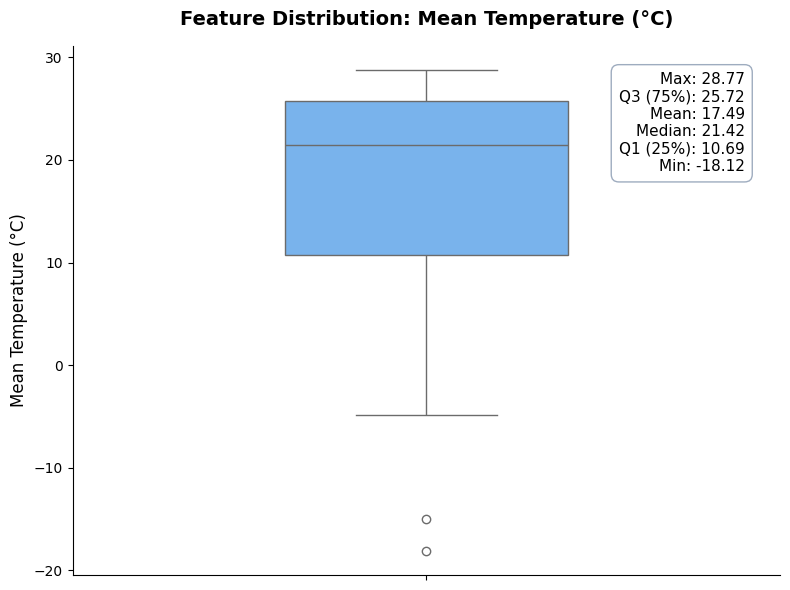

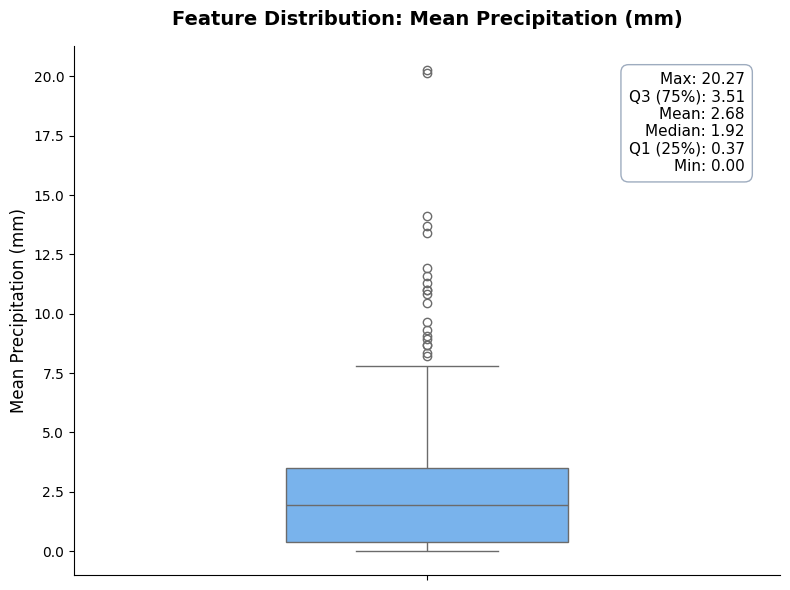

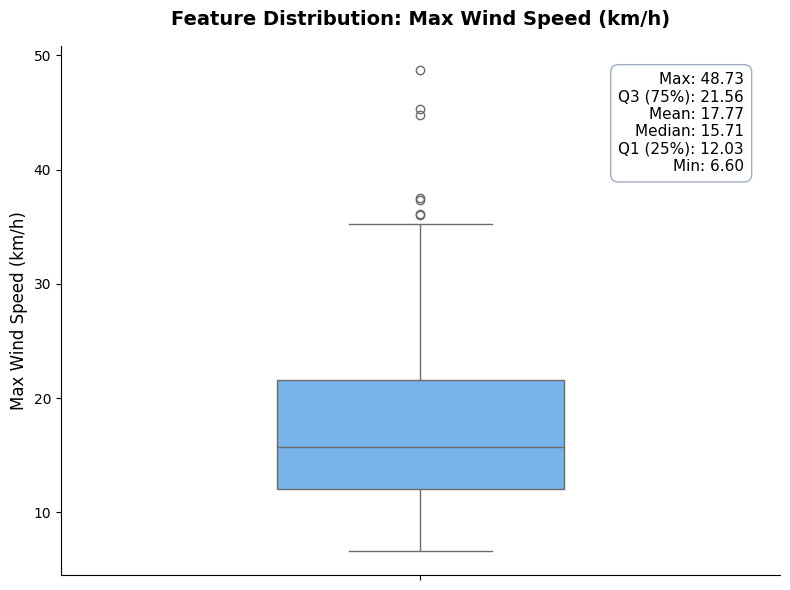

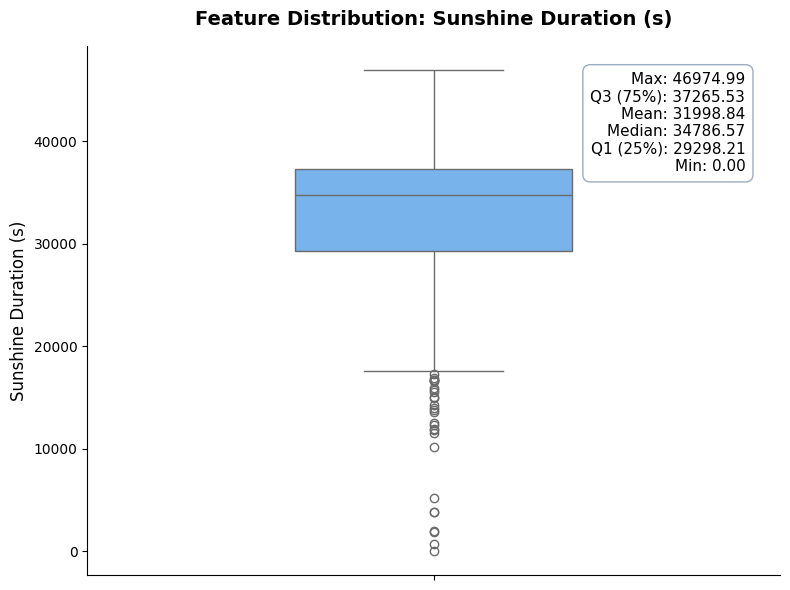

3. Generate Correlation Matrix...


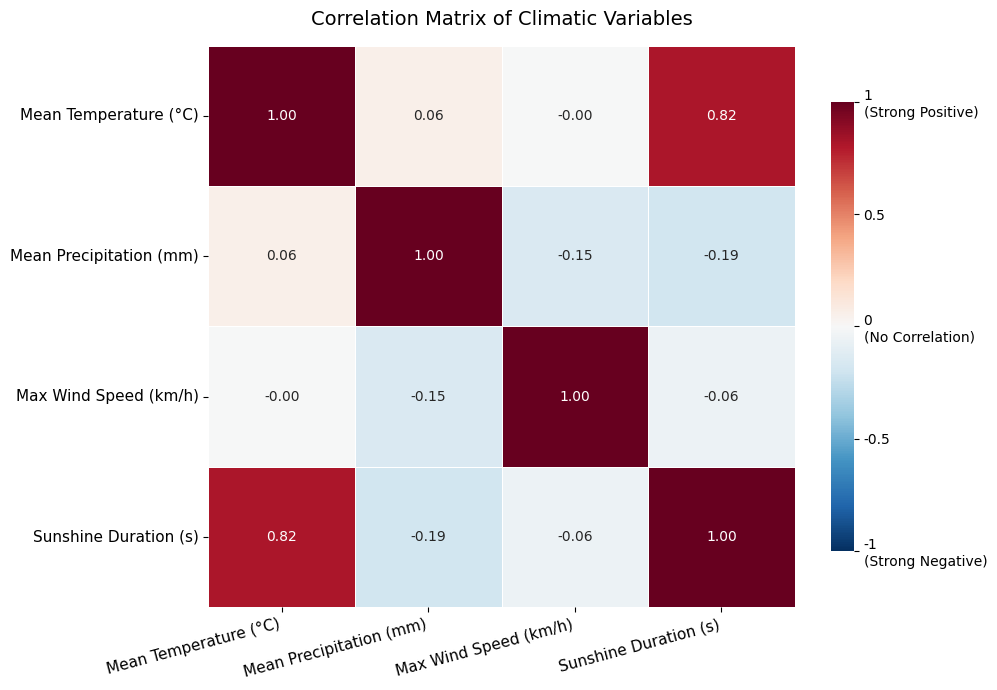

4. Scale data and validate K=4 (Elbow Method)...


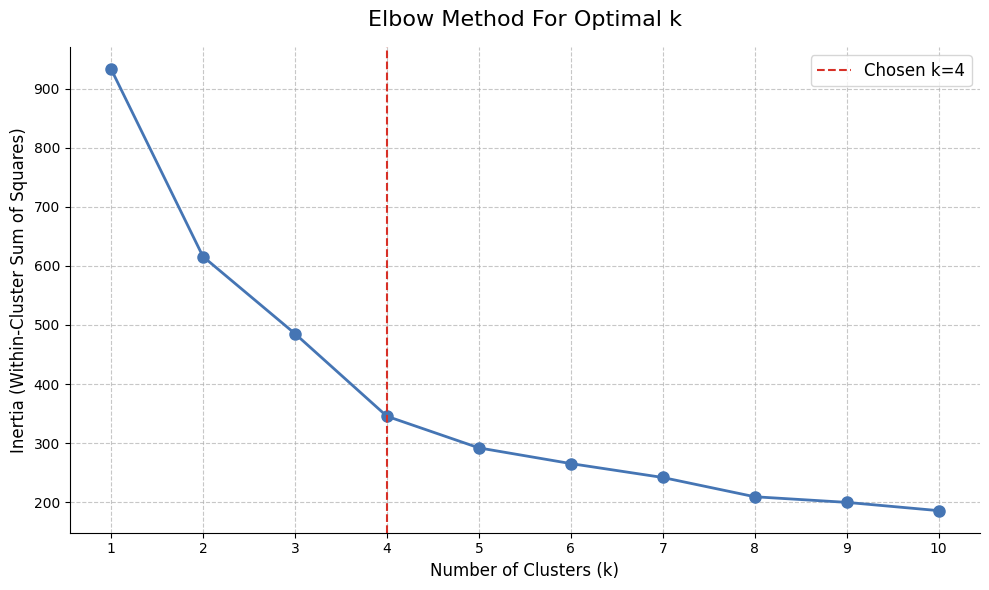

5. Training final model and filtering complete history...
6. Statistical validation of clusters  ...


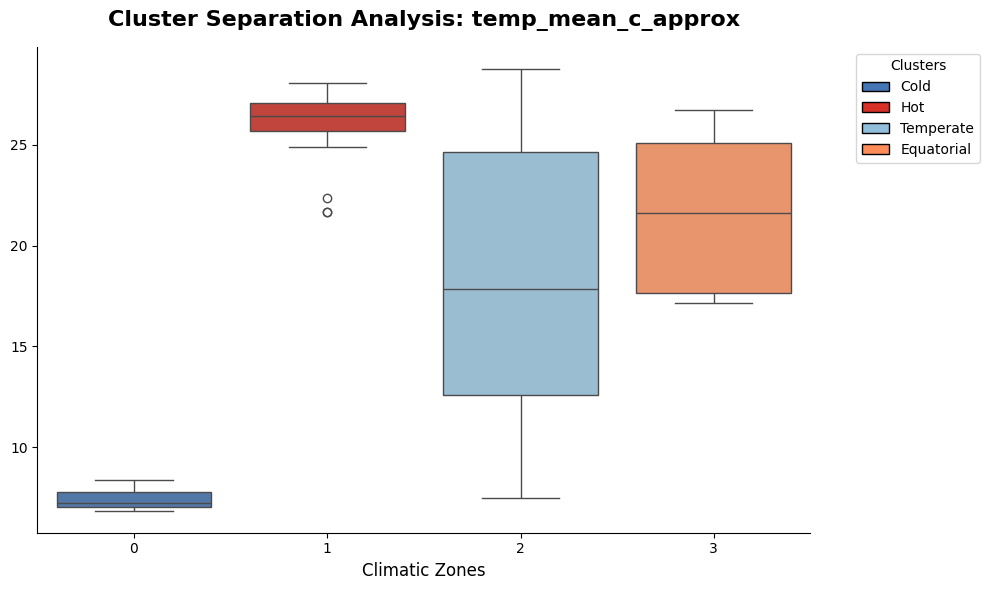

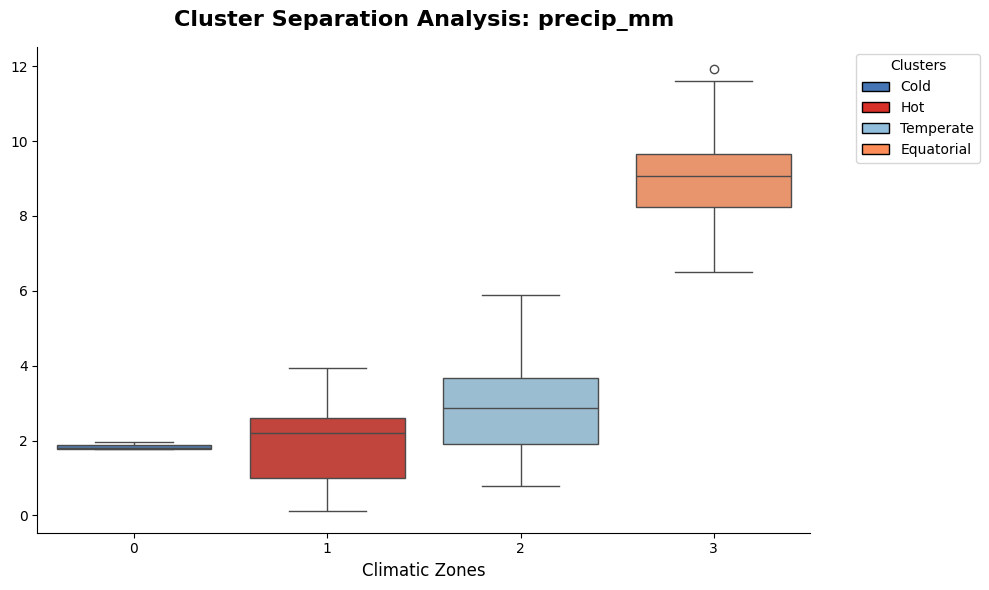

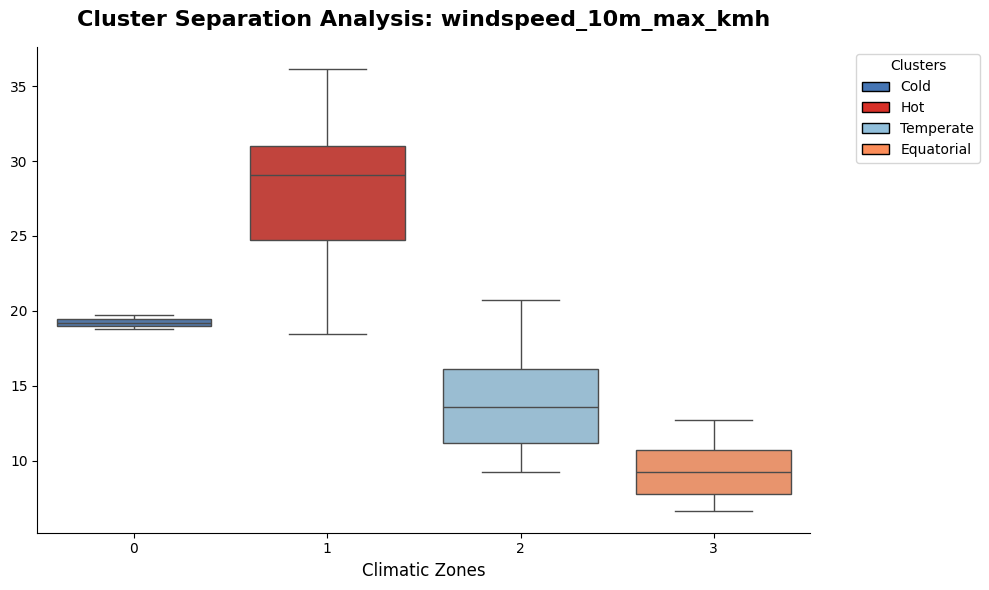

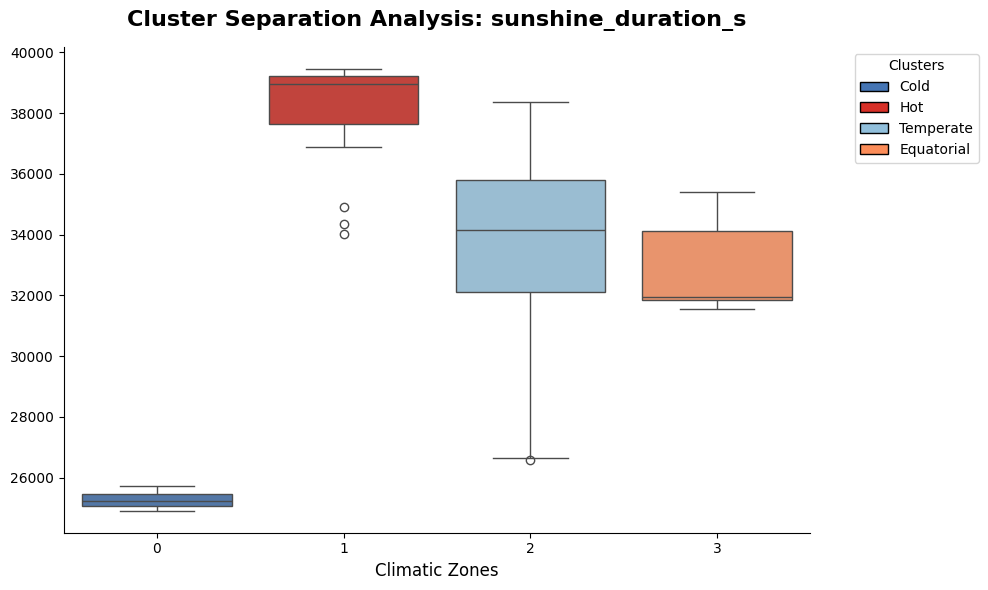

7. Extracting centroids...


Loading ITables v2.8.1 from the init_notebook_mode cell... (need help?)


Number of countries with a complete history across all decades: 41
8. Generate decadal maps...


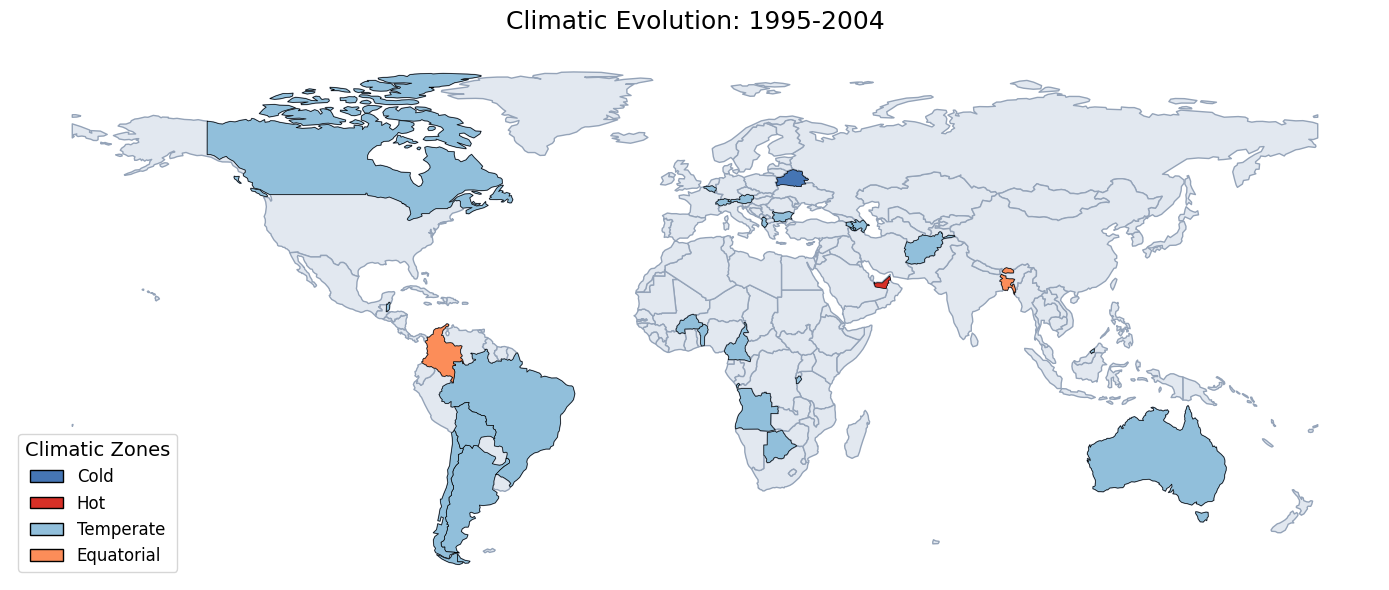

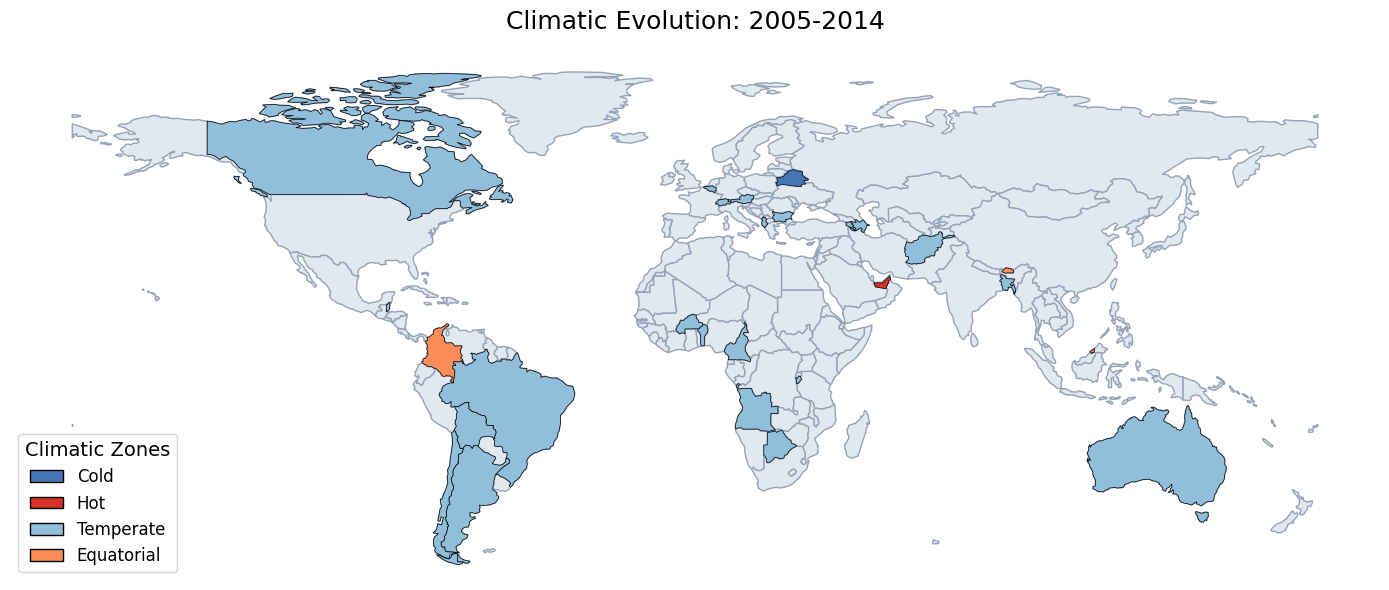

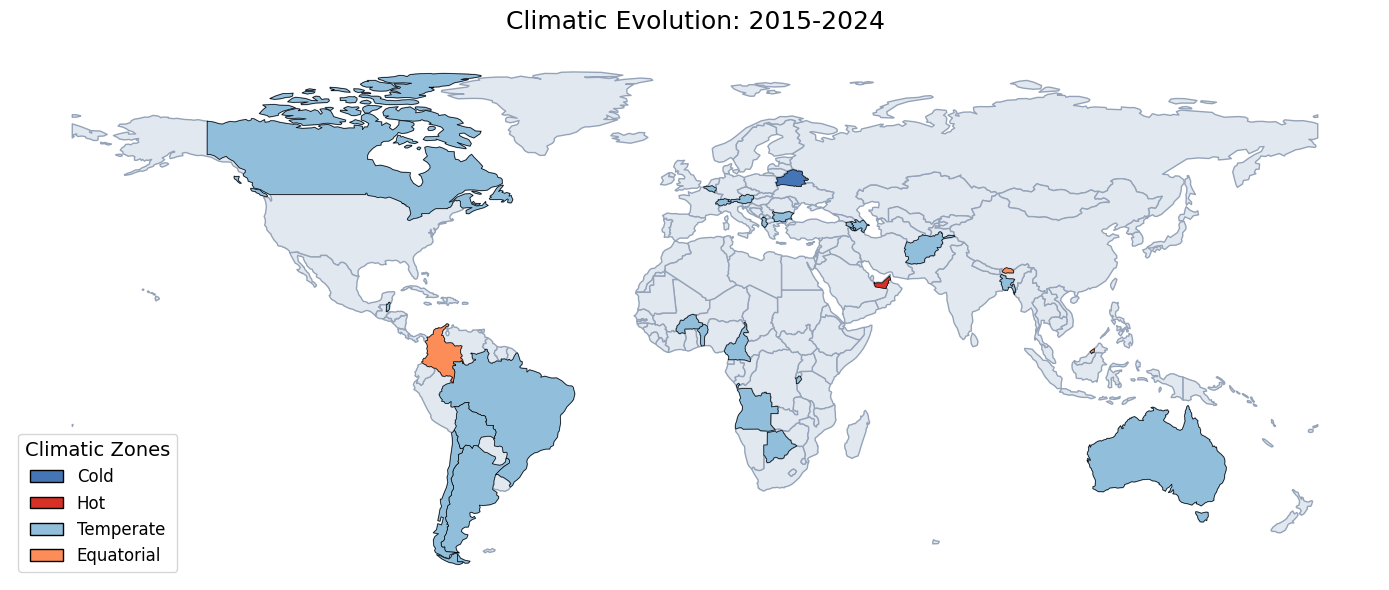

9. Analysing climatic transitions...
------------------------------------------------------------
Number of countries that shifted climate between Decade 1 and Decade 2: 2
------------------------------------------------------------


Loading ITables v2.8.1 from the init_notebook_mode cell... (need help?)



Number of countries that shifted climate between Decade 2 and Decade 3: 0
Project executed successfully!


In [44]:
from itables import init_notebook_mode, show
init_notebook_mode(all_interactive=False)
import kagglehub
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import geopandas as gpd
import geodatasets
from shapely.geometry import Point
import numpy as np
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
# Visual variables
cluster_colors = {
    '0': '#4575b4', # Cold 
    '1': '#d73027', # Hot
    '2': '#91bfdb', # Temperated
    '3': '#fc8d59'  # Equatorial
}
cluster_names = {
    '0': 'Cold',
    '1': 'Hot',
    '2': 'Temperate',
    '3': 'Equatorial'
}
feature_labels = {
    'temp_mean_c_approx': 'Mean Temperature (°C)',
    'precip_mm': 'Mean Precipitation (mm)',
    'windspeed_10m_max_kmh': 'Max Wind Speed (km/h)',
    'sunshine_duration_s': 'Sunshine Duration (s)'
}
climate_features = ['temp_mean_c_approx', 'precip_mm', 'windspeed_10m_max_kmh', 'sunshine_duration_s']
images_path="images/"
os.makedirs(images_path, exist_ok=True)

def load_and_clean_data(features):
    try:
        # Loading DATABASE
        path = kagglehub.dataset_download("wafaaelhusseini/major-cities-weather-data")
        input_db_path = os.path.join(path, "history.parquet")
        df = pd.read_parquet(input_db_path)
    except FileNotFoundError:
        print("Error: 'history.parquet' not found.")
        return None
    except Exception as e:
        print(f"Error: Dataset load failed -{e}")
        return None

    print(f"   -> Initial number of cities in dataset: {df['city'].nunique()}")
    print(f"   -> Initial number of countries in dataset: {df['country'].nunique()}")
    
    # Division by decade
    df['years'] = pd.to_datetime(df['date']).dt.year
    df['time_period'] = pd.cut(df['years'],
                               bins=[1994, 2004, 2014, 2024],
                               labels=['1995-2004', '2005-2014', '2015-2024'])
    
    # Aggregation and grouping by county and decade
    df_temporal = df.groupby(['country', 'time_period'], observed=True).agg({
        'temp_mean_c_approx': 'mean',
        'precip_mm': 'mean',
        'windspeed_10m_max_kmh': 'mean',
        'sunshine_duration_s': 'mean',
        'lat': 'mean',
        'lon': 'mean'
    }).reset_index()
    
    try:
        # Checking and eliminate the row with null relevant features
        df_temporal = df_temporal.dropna(subset=features)
    except KeyError as e:
        print(f"{e}")
        return None
    return df_temporal


def plot_global_distributions(df,features,labels_dict,img_path):
    # Outliers, Means, Quartiles for any of the features
    for feature in features:
    
        plt.figure(figsize=(8,6))
        ax = sns.boxplot(y=df[feature], color='#66b3ff', width=0.4)

        min_val = df[feature].min()
        q1 = df[feature].quantile(0.25)
        median = df[feature].median()
        mean = df[feature].mean()
        q3 = df[feature].quantile(0.75)
        max_val = df[feature].max()

        stats_text = (
            f"Max: {max_val:.2f}\n"
            f"Q3 (75%): {q3:.2f}\n"
            f"Mean: {mean:.2f}\n"
            f"Median: {median:.2f}\n"
            f"Q1 (25%): {q1:.2f}\n"
            f"Min: {min_val:.2f}"
        )
        
        ax.text(0.95, 0.95, stats_text, 
                transform=ax.transAxes, 
                fontsize=11, 
                verticalalignment='top', 
                horizontalalignment='right',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='#94a3b8'))
        
        title=labels_dict[feature]
        plt.title(f'Feature Distribution: {title}', fontweight='bold', fontsize=14, pad=15)
        plt.ylabel(title,fontsize=12)
        plt.xlabel('')
    
        sns.despine()
        plt.tight_layout()
        plt.savefig(f'{img_path}01_boxplots_{feature}.png',bbox_inches='tight')
        plt.show()

def plot_correlation_matrix(df, features, labels_dict, img_path):
    plt.figure(figsize=(10, 7))
    correlation_matrix = df[features].corr()

    ax = sns.heatmap(
        correlation_matrix, 
        annot=True, 
        cmap='RdBu_r', 
        vmin=-1, 
        vmax=1, 
        linewidths=0.5, 
        fmt=".2f",
        cbar_kws={"shrink": 0.8}
    )

    clean_labels = [labels_dict[f] for f in features]
    ax.set_xticklabels(clean_labels, rotation=45, ha='right', fontsize=11)
    ax.set_yticklabels(clean_labels, rotation=0, fontsize=11)
    
    cbar = ax.collections[0].colorbar
    cbar.set_ticks([-1, -0.5, 0, 0.5, 1])
    
    cbar.set_ticklabels([
        '-1\n(Strong Negative)', 
        '-0.5', 
        '0\n(No Correlation)', 
        '0.5', 
        '1\n(Strong Positive)'
    ])
    
    plt.title('Correlation Matrix of Climatic Variables', fontsize=14, pad=15)
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.savefig(f'{img_path}02_correlation_heatmap.png',bbox_inches='tight')
    plt.show()
    
def scale_and_plot_elbow(df,features,img_path):
    # Standardization of the data
    scaler = RobustScaler()
    scaled_data = scaler.fit_transform(df[climate_features])

    # Elbow Method to determine the optimal number of clusters
    inertias = []
    k_range = range(1, 11)
    
    for k in k_range:
        kmeans_test = KMeans(n_clusters=k, random_state=42, n_init='auto')
        kmeans_test.fit(scaled_data)
        inertias.append(kmeans_test.inertia_)
    
    # Plotting the Elbow Graph
    plt.figure(figsize=(10, 6))
    plt.plot(k_range, inertias, marker='o', linestyle='-', color='#4575b4', markersize=8, linewidth=2)
    
    plt.title('Elbow Method For Optimal k', fontsize=16, pad=15)
    plt.xlabel('Number of Clusters (k)', fontsize=12)
    plt.ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
    plt.xticks(k_range)
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # Highlighting the chosen optimal k=4
    plt.axvline(x=4, color='#d73027', linestyle='--', label='Chosen k=4')
    plt.legend(fontsize=12)
    
    # Eliminating unnecessary borders for a cleaner look
    sns.despine()
    
    plt.tight_layout()
    plt.savefig(f'{img_path}03_elbow_method_k4.png',bbox_inches='tight')
    plt.show()
    
    return scaled_data
    
def train_kmeans_and_filter(df,scaled_data,n_clusters):
    # K-MEANS MODEL
    kmeans = KMeans(n_clusters=4, random_state=42, n_init='auto')
    
    # Assigning labels (cluster 0, 1, 2, or 3) to each country-decade profile
    df['climate_cluster'] = kmeans.fit_predict(scaled_data)
    df['climate_cluster'] = df['climate_cluster'].astype(str)
    
    complete_history_mask = df.groupby('country')['time_period'].transform('count') == 3
    
    df_balanced_panel = df[complete_history_mask].copy()

    return df_balanced_panel
    
def plot_cluster_validation(df_balanced,features,colors,names,label_dict,img_path):
    for feature in features:
        plt.figure(figsize=(10, 6))
        
        sns.boxplot(
            data=df_balanced, 
            x='climate_cluster', 
            y=feature, 
            hue='climate_cluster',
            palette=colors,
            order=['0', '1', '2', '3']
        )
        
        plt.title(f'Cluster Separation Analysis: {feature}', fontweight='bold', fontsize=16, pad=15)
        plt.xlabel('Climatic Zones', fontsize=12)
        plt.ylabel('')
        
        handles = [mpatches.Patch(facecolor=color, edgecolor='black', label=names[c_id]) 
                   for c_id, color in colors.items()]
        plt.legend(handles=handles, title='Clusters', bbox_to_anchor=(1.05, 1), loc='upper left')
        
        sns.despine()
        plt.tight_layout()
        plt.savefig(f'{img_path}05_cluster_validation_{feature}.png', dpi=300, bbox_inches='tight', transparent=True)
        plt.show()

def extract_and_show_centroids(df_balanced,features,names):
    # Aggregating the empirical data to compute the mean value of each climate feature per cluster
    df_cluster_profiles = df_balanced.groupby('climate_cluster', observed=True)[features].mean().reset_index()
    
    # Mapping the discrete cluster identifiers to their corresponding descriptive climate names
    df_cluster_profiles['cluster_name'] = df_cluster_profiles['climate_cluster'].map(names)
    ordered_columns = ['climate_cluster', 'cluster_name'] + features
    df_cluster_profiles = df_cluster_profiles[ordered_columns]
    
    # Displaying the structured mathematical profiles of the generated climatic zones
    show(df_cluster_profiles)
    print(f"Number of countries with a complete history across all decades: {df_balanced['country'].nunique()}")

    return df_cluster_profiles

def generate_decadal_maps(df_balanced, colors, names, img_path):
    # Load of the world map 
    url_harta_tari = "https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_110m_admin_0_countries.geojson"
    try:
        world = gpd.read_file(url_harta_tari)
    except Exception as e:
        print(f"Error: Map download failed - {e}. Skipping.")
        return
        
    # Division of the main database in 3 specific one's
    df_1995_2004 = df_balanced[df_balanced['time_period'] == '1995-2004'].copy()
    df_2005_2014 = df_balanced[df_balanced['time_period'] == '2005-2014'].copy()
    df_2015_2024 = df_balanced[df_balanced['time_period'] == '2015-2024'].copy()
    
    # Geographical plot drawing
    dfs = [df_1995_2004, df_2005_2014, df_2015_2024]
    titles = ['Climatic Evolution: 1995-2004', 'Climatic Evolution: 2005-2014', 'Climatic Evolution: 2015-2024']
    files_names=['1995_2004','2005_2014','2015_2024']
    
    for i in range(len(dfs)):
        current_df = dfs[i]
        fig, ax = plt.subplots(figsize=(14, 8))
        world_merged = world.merge(current_df, left_on='NAME', right_on='country', how='left')
        world.plot(ax=ax, color='#e2e8f0', edgecolor='#94a3b8')
        for cluster_id, culoare in colors.items():
            subset = world_merged[world_merged['climate_cluster'] == cluster_id]
            
            if not subset.empty:
                subset.plot(
                    ax=ax,
                    color=culoare,
                    edgecolor='black',
                    linewidth=0.5
                )
    
        ax.set_title(titles[i], fontsize=18, pad=15)
        ax.set_axis_off()
        ax.set_ylim(-60, 90) 
        
       # Legend 
        legend_patches=[]
        for c_id,color in colors.items():
            patch = mpatches.Patch(facecolor=color,edgecolor='black',label=names[c_id])
            legend_patches.append(patch)
        ax.legend(handles=legend_patches, loc='lower left',title='Climatic Zones',fontsize=12,title_fontsize=14)
      
        plt.tight_layout()
        plt.savefig(f'{img_path}04_map_{files_names[i]}.png',bbox_inches='tight')
        plt.show()
        

def calculate_shifts(df_balanced):

    # Division of the main database in 3 specific one's
    df_1995_2004 = df_balanced[df_balanced['time_period'] == '1995-2004'].copy()
    df_2005_2014 = df_balanced[df_balanced['time_period'] == '2005-2014'].copy()
    df_2015_2024 = df_balanced[df_balanced['time_period'] == '2015-2024'].copy()
    
    # Searching for changes during the decades 
    decade_1 = df_1995_2004[['country', 'climate_cluster']].rename(columns={'climate_cluster': 'Climate_1995_2004'})
    decade_2 = df_2005_2014[['country', 'climate_cluster']].rename(columns={'climate_cluster': 'Climate_2005_2014'})
    decade_3 = df_2015_2024[['country', 'climate_cluster']].rename(columns={'climate_cluster': 'Climate_2015_2024'})
    
    transition_1_2 = pd.merge(decade_1, decade_2, on='country')
    actual_shifts_1_2 = transition_1_2[transition_1_2['Climate_1995_2004'] != transition_1_2['Climate_2005_2014']]
    
    print("-" * 60)
    print(f"Number of countries that shifted climate between Decade 1 and Decade 2: {len(actual_shifts_1_2)}")
    print("-" * 60)
    if not actual_shifts_1_2.empty:
        show(actual_shifts_1_2)
    
    transition_2_3 = pd.merge(decade_2, decade_3, on='country')
    actual_shifts_2_3 = transition_2_3[transition_2_3['Climate_2005_2014'] != transition_2_3['Climate_2015_2024']]
    
    print("\n" + "=" * 60)
    print(f"Number of countries that shifted climate between Decade 2 and Decade 3: {len(actual_shifts_2_3)}")
    print("=" * 60)
    if not actual_shifts_2_3.empty:
        show(actual_shifts_2_3)

print("1. Loading and preprocessing data ...")
df_cleaned = load_and_clean_data(climate_features)

print("2. Generate EDA Boxplots...")
plot_global_distributions(df_cleaned, climate_features, feature_labels, images_path)

print("3. Generate Correlation Matrix...")
plot_correlation_matrix(df_cleaned, climate_features,feature_labels, images_path)

print("4. Scale data and validate K=4 (Elbow Method)...")
scaled_data = scale_and_plot_elbow(df_cleaned, climate_features, images_path)

print("5. Training final model and filtering complete history...")
df_final = train_kmeans_and_filter(df_cleaned, scaled_data, n_clusters=4)

print("6. Statistical validation of clusters  ...")
plot_cluster_validation(df_final, climate_features, cluster_colors, cluster_names, feature_labels, images_path)

print("7. Extracting centroids...")
cluster_profiles = extract_and_show_centroids(df_final, climate_features, cluster_names)

print("8. Generate decadal maps...")
generate_decadal_maps(df_final, cluster_colors, cluster_names, images_path)

print("9. Analysing climatic transitions...")
calculate_shifts(df_final)

print("Project executed successfully!")